# PySNE Tutorial
## Finding All Solutions with *Spiral Optimization Algorithm* (SPO) + Clustering

PySNE is a Python library for finding all solutions of:
1. Systems of Nonlinear Equations (SNE),
2. Diophantine Equations (integer solutions), and
3. All optima of multimodal functions,

using the *Spiral Dynamics Optimization Algorithm* with clustering technique.

References:
- Sidarto, K. A. & Kania, A. (2015). *Finding all solutions of systems of nonlinear equations using spiral dynamics inspired optimization with clustering.* JACIII, 19(5).
- Sidarto, K. A., Kania, A., & Sumarti, N. (2017). *Finding multiple solutions of multimodal optimization using spiral optimization algorithm with clustering.* MENDEL, 23(1).
- Tambahin 2023
- Tamura, K. & Yasuda, K. (2011). *Spiral Dynamics Inspired Optimization.* JACIII, 15(8).

Tutorial roadmap:
1. Installation (development mode)
2. Spiral Optimization (SPO) — single-objective optimization
3. Finding SNE roots via transformation — still a single solution
4. Clustering — finding all roots
5. Diophantine equations (integer solutions)
6. Multimodal optimization — all optima

## 1. Installation

PySNE is still under development and has not yet been published on PyPI, so installation is done directly from the GitHub repository (`main` branch):

In [ ]:
# Install from GitHub (development mode).
!pip install git+https://github.com/p2ms-optimization/pysne.git

# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

  Cloning https://github.com/p2ms-optimization/pysne.git to /tmp/pip-req-build-al7fueta
  Running command git clone --filter=blob:none --quiet https://github.com/p2ms-optimization/pysne.git /tmp/pip-req-build-al7fueta
  Resolved https://github.com/p2ms-optimization/pysne.git to commit 6b17260909fa0550ba9167f891445ff8c8414b52
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


## 2. Spiral Optimization (SPO) — single-objective optimization

Before diving into finding all solutions, let’s first understand the core engine: `spiral_dynamics_optimization`.

SPO moves $m$ search points in a spiral towards the current best point $x^*$ using the update rule:

$$x_i(k+1) = S_n(r, \theta)\, x_i(k) - \big(S_n(r, \theta) - I_n\big)\, x^*(k)$$

where $S_n = r\,R_n(\theta)$ and $R_n$ is a rotation matrix. The key parameters are:

| Parameter | Meaning | Reference value (Tamura & Yasuda, 2011) |
|---|---|---|
| `m` | number of search points | 20–250 |
| `r` | spiral contraction rate (0 < r < 1) | 0.95 |
| `theta` | rotation angle | $\pi/4$ |
| `k_max` | maximum number of iterations | 100–300 |

As an example, let’s minimize the 2D Rastrigin function — a multimodal function with many local minima, where the global minimum is at $x = (0,0)$ with $f = 0$:

In [ ]:
from pysne.optimizers.sdoa.engine import spiral_dynamics_optimization

def rastrigin(x):
    """Rastrigin n-dimension."""
    x = np.atleast_2d(x)
    val = 10 * x.shape[1] + np.sum(x**2 - 10 * np.cos(2 * np.pi * x), axis=1)
    return val if val.size > 1 else val[0]

domain = [(-3, 10), (-3, 10)]
params = {'m': 100, 'r': 0.95, 'theta': np.pi / 4, 'k_max': 300}

x_star, history = spiral_dynamics_optimization(
    rastrigin, domain, params,
    minimization=True,       # we are looking for the MINIMUM
    return_history=True
)

print("x* =", np.round(x_star, 8))
print("f(x*) =", history[-1])

x* = [-5.e-08  5.e-08]
f(x*) = 1.1262102361797588e-12


/usr/local/lib/python3.12/dist-packages/pysne/initialization/sampling.py:36: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  unit_points = sampler.random(n=num_points)


### 2.1 Experiment: changing parameters

Spiral behavior is strongly influenced by the combination $(r, \theta)$: $r$ close to 1 slows contraction (longer exploration), $\theta$ controls how much the search path “spirals”. Let’s compare several combinations:

In [ ]:
results = []
for r in [0.90, 0.95, 0.99]:
    for theta in [np.pi/6, np.pi/4, np.pi/2]:
        p = {'m': 100, 'r': r, 'theta': theta, 'k_max': 300}
        xs, h = spiral_dynamics_optimization(
            rastrigin, domain, p, minimization=True, return_history=True)
        results.append({'r': r, 'theta': f"{theta/np.pi:.3f}π",
                      'f_best': h[-1], 'x*': np.round(xs, 4)})

pd.DataFrame(results).sort_values('f_best').reset_index(drop=True)

,r,theta,f_best,x*
0,0.90,0.167π,0.000000e+00,"[0.0, 0.0]"
1,0.90,0.250π,0.000000e+00,"[-0.0, 0.0]"
2,0.90,0.500π,0.000000e+00,"[0.0, 0.0]"
3,0.95,0.500π,6.110668e-13,"[-0.0, -0.0]"
4,0.95,0.250π,1.126210e-12,"[-0.0, 0.0]"
5,0.95,0.167π,2.238210e-12,"[-0.0, -0.0]"
6,0.99,0.500π,4.011867e-02,"[-0.0101, -0.0101]"
7,0.99,0.167π,4.154095e-02,"[-0.0102, -0.0102]"
8,0.99,0.250π,8.074878e-02,"[-0.0191, -0.0065]"


# COBA FUNGSI LAIN & coba ubah parameter

you can try another function:
https://en.wikipedia.org/wiki/Test_functions_for_optimization

### Speed Reducer Design Optimization (Mixed-Integer) with SPO

This example applies the Spiral Optimization Algorithm (SPO) from
PySNE to a classic constrained engineering benchmark: the speed
reducer design problem.

#### Modification for (Mixed) Integer Programming

Suppose among the variables $x_1, x_2, \dots, x_n$, a subset
$x_1, \dots, x_i$ must be integer-valued. The modification is simple:
before evaluating $F(\mathbf{x})$, these variables are converted to integer
type (rounded). The spiral search itself remains in continuous space.

Here, only $x_3$ is an integer variable.

#### Problem Formulation

Minimize the total weight:

$$
\begin{aligned}
f(\mathbf{x}) ={}& 0.7854\,x_1 x_2^2\left(3.3333\,x_3^2 + 14.9334\,x_3 - 43.0934\right) \\
&- 1.508\,x_1\left(x_6^2 + x_7^2\right) + 7.4777\left(x_6^3 + x_7^3\right)
+ 0.7854\left(x_4 x_6^2 + x_5 x_7^2\right)
\end{aligned}
$$

subject to 11 inequality constraints $g_i(\mathbf{x}) \le 0$ and bounds:
$x_1 \in [2.6, 3.6]$, $x_2 \in [0.7, 0.8]$, $x_3 \in [17, 28]$ (integer),
$x_4 \in [7.3, 8.3]$, $x_5 \in [7.8, 8.3]$, $x_6 \in [2.9, 3.9]$, $x_7 \in [5.0, 5.5]$.

In [ ]:
"""
Speed Reducer Design Optimization (Mixed-Integer) with SPO and Penalty Function.
"""

import time
import numpy as np
from pysne.optimizers.sdoa.engine import spiral_dynamics_optimization

# ------------------ 1. DEFINE PROBLEM ------------------

def f_vec(x):
    """Objective function. Accepts 1D input of shape (7,) or 2D of shape (k, 7)."""
    X = np.atleast_2d(np.asarray(x, dtype=float))
    x1, x2, x3, x4, x5, x6, x7 = X.T
    out = (0.7854 * x1 * x2**2 * (3.3333 * x3**2 + 14.9334 * x3 - 43.0934)
           - 1.508 * x1 * (x6**2 + x7**2)
           + 7.4777 * (x6**3 + x7**3)
           + 0.7854 * (x4 * x6**2 + x5 * x7**2))
    return out[0] if np.asarray(x).ndim == 1 else out


def constraints_vec(x):
    """The 11 constraints g_i(x). Accepts 1D (7,) -> (11,), or 2D (k, 7) -> (k, 11)."""
    X = np.atleast_2d(np.asarray(x, dtype=float))
    x1, x2, x3, x4, x5, x6, x7 = X.T
    g = np.empty((X.shape[0], 11))
    g[:, 0]  = 27 / (x1 * x2**2 * x3) - 1
    g[:, 1]  = 397.5 / (x1 * x2**2 * x3**2) - 1
    g[:, 2]  = (1.93 * x4**3) / (x2 * x3 * x6**4) - 1
    g[:, 3]  = (1.93 * x5**3) / (x2 * x3 * x7**4) - 1   # standard g4 (counterpart of g3)
    g[:, 4]  = (1.0 / (110 * x6**3)) * np.sqrt((745.0 * x4 / (x2 * x3))**2 + 16.9e6) - 1
    g[:, 5]  = (1.0 / (85 * x7**3)) * np.sqrt((745.0 * x5 / (x2 * x3))**2 + 157.5e6) - 1
    g[:, 6]  = (x2 * x3) / 40 - 1
    g[:, 7]  = (5 * x2) / x1 - 1
    g[:, 8]  = x1 / (12 * x2) - 1
    g[:, 9]  = (1.5 * x6 + 1.9) / x4 - 1
    g[:, 10] = (1.1 * x7 + 1.9) / x5 - 1
    return g[0] if np.asarray(x).ndim == 1 else g


# ------------------ 2. PENALTY FUNCTION (DEATH PENALTY + EXTERIOR PENALTY) ------------------

M_PENALTY = 1e15
LOW  = np.array([2.6, 0.7, 17.0, 7.3, 7.8, 2.9, 5.0])
HIGH = np.array([3.6, 0.8, 28.0, 8.3, 8.3, 3.9, 5.5])


def round_integers(X):
    """Mixed-integer handling: round x3 (the only integer variable)."""
    X = X.copy()
    X[:, 2] = np.clip(np.round(X[:, 2]), 17, 28)
    return X


def penalty_eval(points):
    """F(x) = f(x) + M * sum(max(0, g_i(x))); points outside the domain -> np.inf.
    Fully vectorized, supports 1D (7,) and 2D (k, 7) inputs."""
    P = np.atleast_2d(np.asarray(points, dtype=float))
    out = np.full(P.shape[0], np.inf)
    inside = np.all((P >= LOW) & (P <= HIGH), axis=1)
    if inside.any():
        X = round_integers(P[inside])
        g = constraints_vec(X)                          # (k, 11)
        viol = np.sum(np.maximum(0.0, g), axis=1)       # (k,)
        out[inside] = f_vec(X) + M_PENALTY * viol
    return out[0] if np.asarray(points).ndim == 1 else out

# ------------------ 3. SPO SETUP ------------------

domain = list(zip(LOW, HIGH))
params = {
    'm': 30000,
    'r': 0.99,
    'theta': np.pi / 32,
    'k_max': 2000
}

print("Running Speed Reducer (Mixed-Integer) optimization with SPO...")
print(f"Population: {params['m']}, Max iterations: {params['k_max']}, "
      f"r={params['r']}, theta=pi/{int(round(np.pi / params['theta']))}")

# ------------------ 4. RUN THE OPTIMIZATION ------------------

t0 = time.perf_counter()
best_x, history = spiral_dynamics_optimization(
    objective_func=penalty_eval,
    domain=domain,
    params=params,
    minimization=True,
    return_history=True
)
elapsed = time.perf_counter() - t0

# ------------------ 5. DISPLAY RESULTS ------------------

final_x = round_integers(best_x[None])[0]     # ensure x3 is integer
final_f_x = f_vec(final_x)
g_final = constraints_vec(final_x)
violation_sum_final = np.sum(np.maximum(0, g_final))
final_penalty = final_f_x + M_PENALTY * violation_sum_final


print("\n" + "=" * 60)
print("SPEED REDUCER OPTIMIZATION RESULTS")
print("=" * 60)
for i in range(7):
    # tag = "  <--- INTEGER" if i == 2 else ""
    val = f"{int(final_x[i])}" if i == 2 else f"{final_x[i]:.6f}"
    print(f"x{i+1}  = {val}")
print("-" * 60)
print(f"Actual objective f(x)  = {final_f_x:.8f}")
print(f"Penalized value F(x)   = {final_penalty:.8f} (= f(x) if feasible)")
print(f"Best value from SPO history = {history[-1]:.8f}")

violations = g_final[g_final > 0]
if len(violations) == 0:
    print("\nSTATUS: FEASIBLE (all g_i <= 0)")
else:
    print(f"\nSTATUS: INFEASIBLE ({len(violations)} constraint(s) still violated)")
    print(f"Violating g_i values: {violations}")

print("\nAll g_i values:")
for i, gi in enumerate(g_final, 1):
    print(f"  g{i:2d} = {gi:.6e}")

print(f"\nExecution time: {elapsed:.2f} s")

/usr/local/lib/python3.12/dist-packages/pysne/initialization/sampling.py:36: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  unit_points = sampler.random(n=num_points)


Running Speed Reducer (Mixed-Integer) optimization with SPO...
Population: 30000, Max iterations: 2000, r=0.99, theta=pi/32

SPEED REDUCER OPTIMIZATION RESULTS
x1  = 3.500000
x2  = 0.700000
x3  = 17
x4  = 7.313985
x5  = 7.810357
x6  = 3.350241
x7  = 5.286687
------------------------------------------------------------
Actual objective f(x)  = 2996.70771991
Penalized value F(x)   = 2996.70771991 (= f(x) if feasible)
Best value from SPO history = 2996.70771991

STATUS: FEASIBLE (all g_i <= 0)

All g_i values:
  g 1 = -7.391528e-02
  g 2 = -1.979985e-01
  g 3 = -4.963041e-01
  g 4 = -9.010789e-01
  g 5 = -6.411057e-10
  g 6 = -2.943290e-11
  g 7 = -7.025000e-01
  g 8 = -9.619527e-12
  g 9 = -5.833333e-01
  g10 = -5.313433e-02
  g11 = -1.216359e-02

Execution time: 38.02 s


## 3. Finding Roots of Systems of Nonlinear Equations — Transformation

The problem of finding all roots of a system $f_i(\mathbf{x}) = 0,\ i = 1, \dots, m$, with $\mathbf{x} \in D \subset \mathbb{R}^n$, is transformed into a maximization problem:

$$F(\mathbf{x}) = \frac{1}{1 + \displaystyle\sum_{i=1}^{m} |f_i(\mathbf{x})|}$$

The key property: $0 < F(\mathbf{x}) \le 1$, and $F(\mathbf{x}) = 1$ if and only if $\mathbf{x}$ is a root of the system. Thus finding all roots is equivalent to finding all points where $F(\mathbf{x}) = 1$, i.e., all global optima of $F$.

We use the system from Sidarto & Kania (2015), Problem 1:

ganti problem 2

# ganti problem 2 dari awal

In [ ]:
from pysne.utils import objective_function
from pysne.optimizers.sdoa.engine import spiral_dynamics_optimization

equations = [
    lambda x: np.exp(x[0] - x[1]) - np.sin(x[0] + x[1]),
    lambda x: x[0]**2 * x[1]**2 - np.cos(x[0] + x[1]),
]

# Fitness: F(x) = 1 / (1 + sum |f_i(x)|), maximized
fitness = lambda x: objective_function(x, equations)

domain_sne = [(-10, 10), (-10, 10)]
params = {'m': 200, 'r': 0.95, 'theta': np.pi / 4, 'k_max': 300}

root, hist = spiral_dynamics_optimization(
    fitness, domain_sne, params,
    minimization=False,      # MAXIMIZATION (default), F -> 1
    return_history=True
)

print("Root candidate:", np.round(root, 6))
print("F(root)       :", hist[-1])
print("Residual      :", [float(abs(f(root))) for f in equations])

Root candidate: [-6.117113 -0.163475]
F(root)       : 0.9999995150279988
Residual      : [1.4158213848189383e-07, 3.4339009791217734e-07]


Geometrically, the roots are the intersection points of the curves $f_1(\mathbf{x}) = 0$ and $f_2(\mathbf{x}) = 0$. Several intersections are visible, yet a single SPO run converges to just one of them:

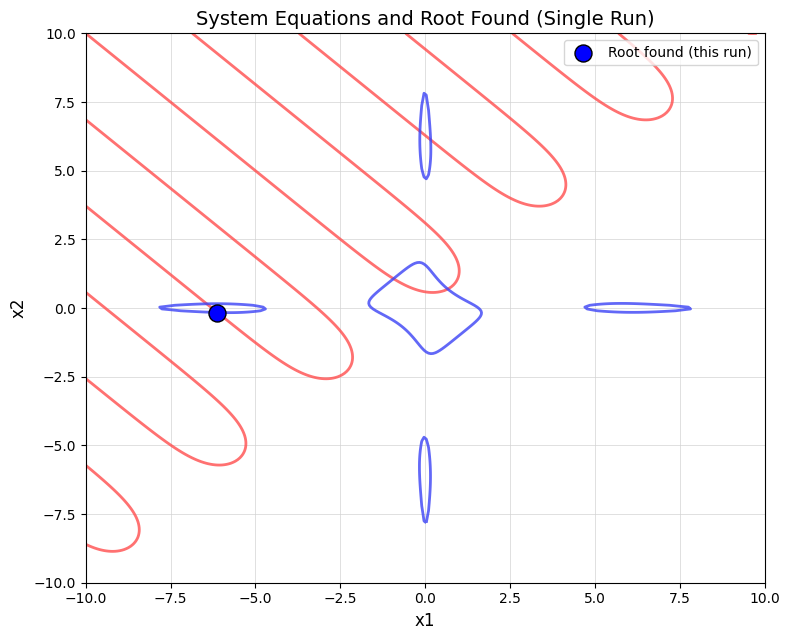

In [ ]:
# Plot the zero-level contour of each equation; intersections = roots
xx, yy = np.meshgrid(np.linspace(-10, 10, 300), np.linspace(-10, 10, 300))

plt.figure(figsize=(8, 6.5))
for eq, color in zip(equations, ['#ff4d4d', '#3b42f5']):
    Z = np.array([[eq(np.array([a, b])) for a, b in zip(rx, ry)]
                  for rx, ry in zip(xx, yy)])
    plt.contour(xx, yy, Z, levels=[0], colors=color, alpha=0.8, linewidths=2)

plt.scatter(root[0], root[1], marker='o', facecolor='blue', edgecolor='black',
            s=150, linewidths=1, label='Root found (this run)', zorder=10)
plt.title('System Equations and Root Found (Single Run)', fontsize=14)
plt.xlabel('x1', fontsize=12); plt.ylabel('x2', fontsize=12)
plt.grid(True, color='lightgray', linestyle='-', linewidth=0.5)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

# Coba problem 1, kira" mendapat akar yang mana

$$\begin{cases} e^{x_1 - x_2} - \sin(x_1 + x_2) = 0 \\ x_1^2 x_2^2 - \cos(x_1 + x_2) = 0 \end{cases}$$

### 3.1 Multiple runs with random initialization → different roots found

The root captured by a run depends on the random initial points: different
initializations pull the spiral toward different basins of attraction. To see
how far repeated single runs can (and cannot) take us, we need a benchmark
with enough roots for the limitation to show.

Problem 2 (Sidarto & Kania, 2015), taken from Tsoulos & Stavrakoudis and
Sacco & Henderson, is such a system:

$$
\begin{aligned}
f_1(x_1, x_2) &= 0.5\sin(x_1 x_2) - \frac{0.25\,x_2}{\pi} - 0.5\,x_1 = 0 \\
f_2(x_1, x_2) &= \left(1 - \frac{0.25}{\pi}\right)\left(e^{2x_1} - e\right)
                 + \frac{e\,x_2}{\pi} - 2e\,x_1 = 0
\end{aligned}
$$

on the domain $D = \{(x_1, x_2) : -1 \le x_1 \le 3,\ -17 \le x_2 \le 4\}$.
It has 12 distinct roots within $D$, including the analytically known
root $(0.5,\ \pi)$. The roots are unevenly distributed: several cluster near
the top of the domain, while others lie far apart along the strip of large
negative $x_2$ — a structure that makes it easy for independent runs to keep
rediscovering the same few roots.

Using the SPO parameters from the reference paper ($m = 300$, $r = 0.95$,
$\theta = \pi/4$, $k_{\max} = 300$), we run the search 100 times
independently, each with a different random uniform initialization, and
count how often each distinct root is found (grouping results closer than
0.05 as the same root):

In [ ]:
import numpy as np
from pysne.utils import objective_function
from pysne.optimizers.sdoa.engine import spiral_dynamics_optimization

# Problem 2 (Sidarto & Kania, 2015)
equations = [
    lambda x: 0.5 * np.sin(x[0] * x[1]) - 0.25 * x[1]/np.pi - 0.5 * x[0],
    lambda x: (1 - 0.25/np.pi) * (np.exp(2*x[0]) - np.e) + np.e * x[1]/np.pi - 2*np.e*x[0]
]

# Fitness: F(x) = 1 / (1 + sum |f_i(x)|), maximized
fitness = lambda x: objective_function(x, equations)

domain_sne = [(-1, 3), (-17, 4)]

# SPO Parameter (Problem 2): m=300, r=0.95, theta=pi/4, k_max=300
params = {'m': 300, 'r': 0.95, 'theta': np.pi / 4, 'k_max': 300}

In [ ]:
from pysne.utils import is_in_domain
import pandas as pd

N_RUNS = 100
lo = np.array([d[0] for d in domain_sne])
hi = np.array([d[1] for d in domain_sne])

found = []
for run in range(N_RUNS):
    rng = np.random.RandomState(run)                      # reproducible per-run seed
    init = rng.uniform(lo, hi, (params['m'], 2))          # RANDOM UNIFORM initialization
    r_found, h = spiral_dynamics_optimization(
        fitness, domain_sne, params,
        custom_initial_points=init,
        equations=equations, epsilon=1e-9,                # early stop when 1 - F <= eps
        return_history=True)
    found.append((r_found, h[-1]))

# Group unique solutions (distance < 0.05) and count frequencies
unique = []                                               # [coords, count, best_F]
for r_found, F in found:
    for u in unique:
        if np.linalg.norm(r_found - u[0]) < 0.05:
            u[1] += 1; u[2] = max(u[2], F); break
    else:
        unique.append([r_found.copy(), 1, F])
unique.sort(key=lambda u: -u[1])

df_runs = pd.DataFrame([{
    'x1': round(c[0], 5), 'x2': round(c[1], 5),
    'frequency': n, 'percentage': f"{n / N_RUNS * 100:.1f}%",
    'best F': f"{F:.8f}", 'in domain': is_in_domain(c, domain_sne),
} for c, n, F in unique])
print(f"{N_RUNS} independent runs -> {len(unique)} distinct solutions obtained:")
df_runs

100 independent runs -> 8 distinct solutions obtained:


,x1,x2,frequency,percentage,best F,in domain
0,0.29945,2.83693,47,47.0%,1.00000000,True
1,0.50000,3.14159,40,40.0%,1.00000000,True
2,-0.26060,0.62253,5,5.0%,0.99999998,True
3,1.29436,-3.13722,4,4.0%,0.99999996,True
4,1.66342,-16.28279,1,1.0%,0.99999996,True
5,1.43395,-6.82077,1,1.0%,0.99999998,True
6,1.48132,-8.38361,1,1.0%,0.99999994,True
7,1.65458,-15.81919,1,1.0%,0.99999991,True


Two problems are now visible from the frequency table. First, the distribution
is heavily biased: 87% of all runs collapse onto just two roots, four other
roots were hit only once each, and the rest fall somewhere in between. Second,
coverage is incomplete — even after 100 independent runs, only 8 of the 12
known roots have been found; a third of the solutions were never discovered at
all. Since each SPO run converges to a single root, and there is no mechanism
steering different runs toward different basins, repeating single runs is an
inefficient and unreliable way to enumerate all solutions. This is where the
clustering technique comes in.

## 4. Clustering — Finding All Roots

The `solve_system` pipeline operates in three phases (Sidarto & Kania, 2015):

1. Iterative clustering — scatter `m_cluster` points (Sobol), run a few spiral steps, detect promising regions as *clusters*;
2. SPO per cluster — run full SDOA within each cluster (one root per cluster);
3. Selection & validation — discard duplicates (distance < `delta`) and candidates with residual > `epsilon`.

Parameter dictionary:

| Group | Parameter | Meaning |
|---|---|---|
| Clustering | `m_cluster` | number of initial points |
| | `k_cluster` | spiral iterations per clustering cycle |
| | `r_cl`, `theta_cl` | spiral parameters for the clustering phase |
| | `gamma` | fitness threshold for retained points |
| SPO | `spo_m`, `spo_k_max`, `r`, `theta` | SDOA parameters per cluster |
| Selection | `epsilon` | residual tolerance for valid roots |
| | `delta` | minimum distance between unique roots |

PySNE provides ready-to-use benchmark problems with pre-calibrated parameters:

diganti problem 2

In [ ]:
# from pysne.problems.benchmarks_sne import get_problem_set
from pysne.solver import solve_system
from pysne.problems.base import SNEProblem

class problem_1(SNEProblem):
    @property
    def name(self):
        return "Problem 1 Benchmark System Non-linear Equation"

    def get_equations(self):
        equations = [
            lambda x: np.exp(x[0] - x[1]) - np.sin(x[0] + x[1]),
            lambda x: x[0]**2 * x[1]**2 - np.cos(x[0] + x[1])
        ]
        return equations

    def get_info(self):
        domain = [(-10, 10), (-10, 10)]
        params = {
            'm_cluster': 250,
            'r_cl': 0.95, # r
            'theta_cl': np.pi/4, # theta
            'k_cluster': 10,
            'epsilon': 1e-7,
            'delta': 0.01,
            'sdoa_m': 250,
            'sdoa_k_max': 270,
            'r': 0.95, # sdoa_r
            'theta': np.pi/4, # sdoa_theta
            'gamma': 0.2
        }
        return domain, params

# built-in alternatives
# problems_sne = get_problem_set()
# prob = problems_sne[1]()
prob_sne = problem_1()

domain, params = prob_sne.get_info()
print("Problem :", prob_sne.name)
print("Domain  :", domain)

result = solve_system(prob_sne, params, verbose=True)

Problem : Problem 1 Benchmark System Non-linear Equation
Domain  : [(-10, 10), (-10, 10)]


/usr/local/lib/python3.12/dist-packages/pysne/initialization/sampling.py:36: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  unit_points = sampler.random(n=num_points)


Search completed in 11.911 seconds.
Found 21 clusters and 6 valid roots.


In [ ]:
# Table of roots + individual residuals
all_roots = result['roots']
df = pd.DataFrame(all_roots, columns=['x1', 'x2'])
df['total_residual'] = [
    sum(abs(f(x)) for f in prob_sne.get_equations()) for x in all_roots
]
df.round(8)

,x1,x2,total_residual
0,-6.117113,-0.163476,4.000000e-08
1,-0.932122,1.067874,5.000000e-08
2,0.667121,0.690103,7.000000e-08
3,-0.155283,6.439836,8.000000e-08
4,0.163333,6.122434,8.000000e-08
5,-6.437163,0.155348,9.000000e-08


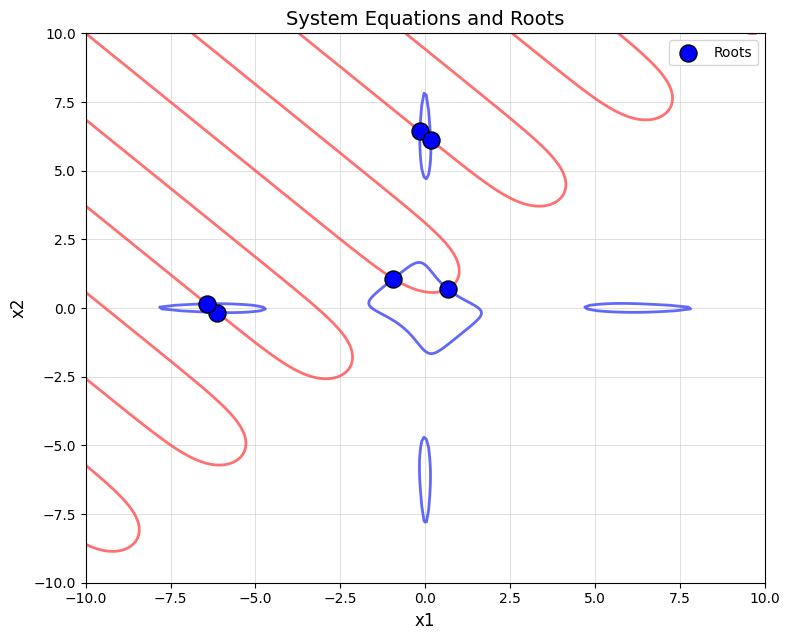

In [ ]:
import matplotlib.pyplot as plt

# Plot all roots found by solve_system on the equation contours
plt.figure(figsize=(8, 6.5))
for eq, color in zip(prob_sne.get_equations(), ['#ff4d4d', '#3b42f5']):
    Z = np.array([[eq(np.array([a, b])) for a, b in zip(rx, ry)]
                  for rx, ry in zip(xx, yy)])
    plt.contour(xx, yy, Z, levels=[0], colors=color, alpha=0.8, linewidths=2)

all_roots = np.array(result['roots'])
plt.scatter(all_roots[:, 0], all_roots[:, 1], marker='o', facecolor='blue',
            edgecolor='black', s=150, linewidths=1, label='Roots', zorder=10)
plt.title('System Equations and Roots', fontsize=14)
plt.xlabel('x1', fontsize=12); plt.ylabel('x2', fontsize=12)
plt.grid(True, color='lightgray', linestyle='-', linewidth=0.5)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

### 4.1 Defining your own SNE problem

Simply subclass `SNEProblem` and implement three things: `name`, `get_equations()`, and `get_info()`:

In [ ]:
from pysne.problems.base import SNEProblem

class MyProblem(SNEProblem):
    @property
    def name(self):
        return "Example: circle & hyperbola"

    def get_equations(self):
        # x^2 + y^2 = 4  and  xy = 1  ->  4 roots
        return [
            lambda x: x[0]**2 + x[1]**2 - 4,
            lambda x: x[0] * x[1] - 1,
        ]

    def get_info(self):
        domain = [(-3, 3), (-3, 3)]
        params = {
            'm_cluster': 512, 'k_cluster': 10,
            'r_cl': 0.95, 'theta_cl': np.pi / 4,
            'gamma': 0.5,                    # recommended for SNE
            'sdoa_m': 128, 'sdoa_k_max': 400,
            'r': 0.95, 'theta': np.pi / 4,
            'epsilon': 1e-7, 'delta': 0.01,
            'expected_roots': 4,
        }
        return domain, params

my_prob = MyProblem()
domain, params = my_prob.get_info()
my_result = solve_system(my_prob, params, verbose=True)
print(np.round(my_result['roots'], 6))

Search completed in 3.128 seconds.
Found 29 clusters and 4 valid roots.
[[-0.517638 -1.931852]
 [ 1.931852  0.517638]
 [-1.931852 -0.517638]
 [ 0.517638  1.931852]]


## 5. Diophantine Equations — Integer Solutions

PySNE can also solve Diophantine equations by combining continuous optimization with integer rounding. Since Spiral Optimization operates in a continuous domain, each integer value is represented by a continuous interval of width 1 (integer bounds ±0.5). During objective evaluation, every candidate solution is rounded to the nearest integer before computing the equation residual.

As a simple example, consider the Diophantine equation

$$
15x + 11y = 12, \qquad x, y \in [-50, 50] \cap \mathbb{Z}.
$$

The search is performed over the corresponding continuous domain, while only rounded integer values are evaluated. Within the bounded search space, this equation has exactly 7 integer solutions, all of which are successfully identified by PySNE in less than one second.

The implementation is very similar to defining an SNE problem. The only difference is that the search domain is specified over integers, while PySNE internally performs optimization over the corresponding continuous intervals.

In [ ]:
from pysne.problems.base import DiophantineProblem

class MyDiophantineProblem(DiophantineProblem):
    @property
    def name(self):
        return "Example: 15x + 11y = 12"

    def get_equations(self):
        return [lambda x: 15*x[0] + 11*x[1] - 12]

    def get_info(self):
        domain = [(-50, 50), (-50, 50)]
        params = {
            'm_cluster': 375, 'k_cluster': 10,
            'r_cl': 0.95, 'theta_cl': np.pi/4,
            'gamma': 0.01,
            'sdoa_m': 30, 'sdoa_k_max': 10,
            'r': 0.95, 'theta': np.pi/4,
            'epsilon': 1e-7, 'delta': 0.1,
            'num_check_points': 3,
            'expected_roots': 7,
            'init_method': 'sobol',
        }
        return domain, params

my_prob = MyDiophantineProblem()
domain, params = my_prob.get_info()
result = solve_system(my_prob, params, verbose=True)
print(np.round(result['roots'], 6))

Search completed in 0.343 seconds.
Found 61 clusters and 7 valid roots.
[[-19.  27.]
 [-30.  42.]
 [ -8.  12.]
 [ 25. -33.]
 [ 14. -18.]
 [  3.  -3.]
 [ 36. -48.]]


/usr/local/lib/python3.12/dist-packages/pysne/initialization/sampling.py:36: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  unit_points = sampler.random(n=num_points)


## 6. Multimodal Optimization — All Optimal

For multimodal functions, the goal is to find all optimal of a multimodal function (not just the global optimal).

Example: Six-Hump Camel Back

In [ ]:
import numpy as np
from pysne.solver import solve
from pysne.problems.base import MultimodalProblem, MinimizedProblem
# from pysne.problems.benchmarks_multimodal import get_multimodal_problems

# 1. Define the problem (example: Six-Hump Camel Back)
# Built-in alternative:
# problems = get_multimodal_problems()
# prob = problems[2]()

class Problem2(MultimodalProblem):
    @property
    def name(self):
        return "Problem 2: Six Hump Camel Back Function"

    def g_func(self, x):
        x = np.asarray(x)
        x1 = x[0] if x.ndim == 1 else x[:, 0]
        x2 = x[1] if x.ndim == 1 else x[:, 1]
        term1 = (4 - 2.1 * x1**2 + (x1**4) / 3) * x1**2
        term2 = x1 * x2
        term3 = (-4 + 4 * x2**2) * x2**2
        return (term1 + term2 + term3)

    def get_info(self):
        domain = [(-1.9, 1.9), (-1.1, 1.1)]
        params = {
            'm_cluster': 300,
            'r_cl': 0.95,
            'theta_cl': np.pi/4,
            'k_cluster': 5,
            'epsilon': 1e-5,
            'delta': 0.1,
            'sdoa_m': 50,
            'sdoa_k_max': 250,
            'r': 0.95,
            'theta': np.pi/4,
            'gamma': -float('inf'),
            'num_check_points': 2
        }
        return domain, params

prob_mm = Problem2()

# 2. Get the pre-calibrated domain and default parameters
domain, params = prob_mm.get_info()

# 3. Run the solver -> searches for MAXIMUM points
result_max = solve(prob_mm, params, verbose=True)

print(result_max['optimals'])        # array of solution coordinates
print(result_max['time_elapsed'])    # execution time (seconds)
print(f"Maximum found: {len(result_max['optimals'])} points")

Search completed in 1.012 seconds.
Found 93 clusters and 2 valid optimal solutions.
[[ 1.23022988  0.16233459]
 [-1.23022988 -0.16233459]]
1.011873483657837
Maximum found: 2 points


By default the solver searches for maximum; to find minimum, wrap the problem with `MinimizedProblem`:

In [ ]:
from pysne.problems.base import MinimizedProblem
from pysne.solver import solve

# Wrap the same problem to search for MINIMUM points instead
prob_mm_min = MinimizedProblem(prob_mm)

result_min = solve(prob_mm_min, params, verbose=True)

print(result_min['optimals'])        # array of solution coordinates
print(result_min['time_elapsed'])    # execution time (seconds)
print(f"Minimum found: {len(result_min['optimals'])} points")

Search completed in 1.343 seconds.
Found 109 clusters and 6 valid optimal solutions.
[[-0.08984201  0.7126564 ]
 [ 0.08984202 -0.7126564 ]
 [ 1.70360671 -0.79608357]
 [-1.70360672  0.79608356]
 [ 1.60710476  0.56865146]
 [-1.60710474 -0.56865145]]
1.3432824611663818
Minimum found: 6 points


### 6.1 Defining your own multimodal problem

For multimodal optimization, subclass `MultimodalProblem` and implement three
things: `name`, `g_func()` (the objective function, supporting both a single
point of shape `(n,)` and a batch of shape `(k, n)`), and `get_info()`. By
default the solver searches for all maximum of `g_func`; to find all
minimum instead, wrap the problem in `MinimizedProblem` — no changes to the
objective needed.

The example below uses Himmelblau's function, which has four global minima
and one local maximum inside the domain:

In [ ]:
import numpy as np
from pysne.problems.base import MultimodalProblem, MinimizedProblem
from pysne.solver import solve

class MyProblem(MultimodalProblem):
    @property
    def name(self):
        return "MyProblem: Himmelblau's Function"

    def g_func(self, x):
        x = np.asarray(x)
        x1 = x[0] if x.ndim == 1 else x[:, 0]   # batch-safe: (n,) or (k, n)
        x2 = x[1] if x.ndim == 1 else x[:, 1]
        return (x1**2 + x2 - 11)**2 + (x1 + x2**2 - 7)**2

    def get_info(self):
        domain = [(-5, 5), (-5, 5)]
        params = {
            'm_cluster': 512, 'k_cluster': 10, 'gamma': -float('inf'),
            'sdoa_m': 128, 'sdoa_k_max': 400,
            'r': 0.95, 'theta': np.pi / 4,
            'epsilon': 1e-7, 'delta': 0.01,
            'num_check_points': 1
        }
        return domain, params

prob = MyProblem()
domain, params = prob.get_info()

# Search for all MAXIMA of g_func (default behavior)
result_max = solve(prob, params, verbose=True)
print("Maximum found:\n", result_max['optimals'])

# Wrap the same problem to search for all MINIMA instead
prob_min = MinimizedProblem(prob)
result_min = solve(prob_min, params, verbose=True)
print("Minimum found:\n", result_min['optimals'])

Search completed in 0.690 seconds.
Found 49 clusters and 1 valid optimal solutions.
Maximum found:
 [[-0.27084461 -0.92303852]]
Search completed in 0.672 seconds.
Found 28 clusters and 4 valid optimal solutions.
Minimum found:
 [[ 3.58442834 -1.84812653]
 [ 3.          2.        ]
 [-3.77931025 -3.28318599]
 [-2.80511809  3.13131252]]


## 7. Conclusion

Summary of what we covered:

| Section | Capability | Key function |
|---|---|---|
| 2 | Single-objective optimization | `spiral_dynamics_optimization(...)` |
| 3 | Single root via $F(\mathbf{x})$ transformation | `objective_function` + engine |
| 4 | All SNE roots | `solve_system(SNEProblem, params)` |
| 5 | Integer solutions (Diophantine) | `solve_system(DiophantineProblem, params)` |
| 6 | All multimodal optimal | `solve(MultimodalProblem, params)` + `MinimizedProblem` |

Once PySNE is officially released on PyPI, installation will simply be `pip install pysne` and this tutorial will be updated with a pinned stable release tag.

Repository: https://github.com/p2ms-optimization/pysne